# Step 4: Scoring Engine
## Agregasi Hasil ABSA per Produk

**Tujuan**: 
- Baca hasil ABSA dari `absa_results.csv`
- Agregasi sentimen untuk 4 aspek (Harga, Kualitas, Pengiriman, Layanan) per product_id
- Hitung weighted average score (0-1) untuk setiap produk
- Identifikasi aspek kelemahan (weakness flag)
- Output: CSV dengan product-level metrics untuk Decision Engine

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set up paths
BASE_PATH = Path('../')
ABSA_RESULTS = BASE_PATH / 'absa_results.csv'
OUTPUT_PATH = BASE_PATH / 'product_scores.csv'

print(f"Checking files...")
print(f"ABSA Results exists: {ABSA_RESULTS.exists()}")

Checking files...
ABSA Results exists: True


## 1. Explorasi Data ABSA

In [2]:
# Load ABSA results
df_absa = pd.read_csv(ABSA_RESULTS)

print(f"Shape: {df_absa.shape}")
print(f"\nColumns: {df_absa.columns.tolist()}")
print(f"\nFirst 3 rows:")
print(df_absa.head(3))

Shape: (30000, 13)

Columns: ['review_id', 'product_id', 'review_body', 'star_rating', 'trust_probability', 'harga', 'kualitas', 'pengiriman', 'layanan', 'sentiment_harga', 'sentiment_kualitas', 'sentiment_pengiriman', 'sentiment_layanan']

First 3 rows:
        review_id  product_id  \
0  R366Y8RH9NLUOD  B004GV3AZ6   
1  R19WX2VCQUBRDU  B00BIOMUIW   
2   RYBO7ZXWHMXFQ  B005FVNGZK   

                                         review_body  star_rating  \
0  i bought 2 of these and they both worked great...            4   
1  i'm using this on my at-120 body. it'll fit th...            4   
2  we have had a number of these clips.  the newe...            3   

   trust_probability  harga  kualitas  pengiriman  layanan sentiment_harga  \
0           0.512622  False     False       False    False             NaN   
1           0.614660  False     False       False    False             NaN   
2           0.592101   True     False       False     True        NEGATIVE   

  sentiment_kualitas s

In [3]:
# Cek unique values di sentiment columns
SENTIMENT_COLS = ['sentiment_harga', 'sentiment_kualitas', 'sentiment_pengiriman', 'sentiment_layanan']

print("Sentiment Distribution:")
for col in SENTIMENT_COLS:
    print(f"\n{col}:")
    print(df_absa[col].value_counts(dropna=False))

Sentiment Distribution:

sentiment_harga:
sentiment_harga
NaN         17414
POSITIVE     6571
NEGATIVE     6015
Name: count, dtype: int64

sentiment_kualitas:
sentiment_kualitas
NaN         18862
POSITIVE     6087
NEGATIVE     5051
Name: count, dtype: int64

sentiment_pengiriman:
sentiment_pengiriman
NaN         24229
NEGATIVE     3287
POSITIVE     2484
Name: count, dtype: int64

sentiment_layanan:
sentiment_layanan
NaN         24669
NEGATIVE     3883
POSITIVE     1448
Name: count, dtype: int64


In [4]:
# Cek columns boolean untuk aspek
ASPECT_COLS = ['harga', 'kualitas', 'pengiriman', 'layanan']

print("Aspect Columns (Boolean - present in review):")
for col in ASPECT_COLS:
    print(f"{col}: {df_absa[col].value_counts().to_dict()}")

Aspect Columns (Boolean - present in review):
harga: {False: 17414, True: 12586}
kualitas: {False: 18862, True: 11138}
pengiriman: {False: 24229, True: 5771}
layanan: {False: 24669, True: 5331}


## 2. Scoring Logic

**Konversi Sentimen ke Skor Numerik:**
- POSITIVE → 1.0
- NEUTRAL → 0.5
- NEGATIVE → 0.0
- NaN/tidak ada aspek → 0.5 (netral)

**Agregasi per Product:**
- Mean skor untuk setiap aspek (harga, kualitas, pengiriman, layanan)
- Weighted average dari 4 aspek (equal weight 25% each)
- Product Score = 0-1

**Weakness Flag:**
- Aspek dengan mean score < 0.4 = "WEAKNESS"

In [5]:
# Convert sentiment string to numeric score
def sentiment_to_score(sentiment_val):
    """
    POSITIVE → 1.0
    NEUTRAL → 0.5
    NEGATIVE → 0.0
    NaN → 0.5 (treat as neutral/no mention)
    """
    if pd.isna(sentiment_val):
        return 0.5
    elif sentiment_val == 'POSITIVE':
        return 1.0
    elif sentiment_val == 'NEUTRAL':
        return 0.5
    elif sentiment_val == 'NEGATIVE':
        return 0.0
    else:
        return 0.5

# Apply conversion to all sentiment columns
for col in SENTIMENT_COLS:
    score_col = col.replace('sentiment_', 'score_')
    df_absa[score_col] = df_absa[col].apply(sentiment_to_score)

print("Sample converted scores:")
print(df_absa[['sentiment_harga', 'score_harga', 'sentiment_kualitas', 'score_kualitas']].head(10))

Sample converted scores:
  sentiment_harga  score_harga sentiment_kualitas  score_kualitas
0             NaN          0.5                NaN             0.5
1             NaN          0.5                NaN             0.5
2        NEGATIVE          0.0                NaN             0.5
3        POSITIVE          1.0           POSITIVE             1.0
4        NEGATIVE          0.0           NEGATIVE             0.0
5             NaN          0.5           NEGATIVE             0.0
6             NaN          0.5           POSITIVE             1.0
7        NEGATIVE          0.0                NaN             0.5
8        POSITIVE          1.0           POSITIVE             1.0
9             NaN          0.5                NaN             0.5


## 3. Aggregasi per Product

In [6]:
# Group by product_id and calculate mean scores
SCORE_COLS = ['score_harga', 'score_kualitas', 'score_pengiriman', 'score_layanan']

product_scores = df_absa.groupby('product_id')[SCORE_COLS].agg(['mean', 'count']).reset_index()

# Flatten multi-level columns
product_scores.columns = ['_'.join(col).strip('_') if col[1] else col[0] for col in product_scores.columns.values]

print(f"Products found: {len(product_scores)}")
print(f"\nFirst 5 products:")
print(product_scores.head())

Products found: 14948

First 5 products:
   product_id  score_harga_mean  score_harga_count  score_kualitas_mean  \
0  0966185056          0.500000                  2                0.500   
1  0972683275          0.666667                  3                0.500   
2  1400501776          0.500000                  1                1.000   
3  1400532620          0.500000                  2                0.500   
4  1400532655          0.312500                  8                0.375   

   score_kualitas_count  score_pengiriman_mean  score_pengiriman_count  \
0                     2               0.500000                       2   
1                     3               0.333333                       3   
2                     1               0.500000                       1   
3                     2               0.500000                       2   
4                     8               0.500000                       8   

   score_layanan_mean  score_layanan_count  
0               0.

In [7]:
# Bersihkan dan rename columns
# Ambil mean untuk setiap aspek
aspect_cols_mean = ['score_harga_mean', 'score_kualitas_mean', 'score_pengiriman_mean', 'score_layanan_mean']
aspect_cols_count = ['score_harga_count', 'score_kualitas_count', 'score_pengiriman_count', 'score_layanan_count']

# Rename untuk clarity
rename_map = {
    'score_harga_mean': 'aspect_harga_score',
    'score_kualitas_mean': 'aspect_kualitas_score',
    'score_pengiriman_mean': 'aspect_pengiriman_score',
    'score_layanan_mean': 'aspect_layanan_score',
}

product_scores = product_scores.rename(columns=rename_map)

# Total review count per product
product_scores['review_count'] = df_absa.groupby('product_id').size().values

print(product_scores.head())

   product_id  aspect_harga_score  score_harga_count  aspect_kualitas_score  \
0  0966185056            0.500000                  2                  0.500   
1  0972683275            0.666667                  3                  0.500   
2  1400501776            0.500000                  1                  1.000   
3  1400532620            0.500000                  2                  0.500   
4  1400532655            0.312500                  8                  0.375   

   score_kualitas_count  aspect_pengiriman_score  score_pengiriman_count  \
0                     2                 0.500000                       2   
1                     3                 0.333333                       3   
2                     1                 0.500000                       1   
3                     2                 0.500000                       2   
4                     8                 0.500000                       8   

   aspect_layanan_score  score_layanan_count  review_count  
0      

In [8]:
# Calculate weighted average (equal weight 25% each aspect)
aspect_score_cols = ['aspect_harga_score', 'aspect_kualitas_score', 'aspect_pengiriman_score', 'aspect_layanan_score']

product_scores['product_score'] = product_scores[aspect_score_cols].mean(axis=1)

print(f"Product Score Stats:")
print(product_scores['product_score'].describe())
print(f"\nSample products with scores:")
print(product_scores[['product_id', 'review_count', 'aspect_harga_score', 'aspect_kualitas_score', 
                       'aspect_pengiriman_score', 'aspect_layanan_score', 'product_score']].head(10))

Product Score Stats:
count    14948.000000
mean         0.488279
std          0.171161
min          0.000000
25%          0.375000
50%          0.500000
75%          0.625000
max          1.000000
Name: product_score, dtype: float64

Sample products with scores:
   product_id  review_count  aspect_harga_score  aspect_kualitas_score  \
0  0966185056             2            0.500000               0.500000   
1  0972683275             3            0.666667               0.500000   
2  1400501776             1            0.500000               1.000000   
3  1400532620             2            0.500000               0.500000   
4  1400532655             8            0.312500               0.375000   
5  140053271X             8            0.500000               0.562500   
6  1400599997             9            0.388889               0.333333   
7  1585747416             1            0.000000               0.500000   
8  1591399459             1            0.000000               0.000000 

## 4. Identifikasi Weakness Flags

In [9]:
# Identify weaknesses (score < 0.4)
WEAKNESS_THRESHOLD = 0.4

def identify_weaknesses(row):
    weaknesses = []
    if row['aspect_harga_score'] < WEAKNESS_THRESHOLD:
        weaknesses.append('HARGA')
    if row['aspect_kualitas_score'] < WEAKNESS_THRESHOLD:
        weaknesses.append('KUALITAS')
    if row['aspect_pengiriman_score'] < WEAKNESS_THRESHOLD:
        weaknesses.append('PENGIRIMAN')
    if row['aspect_layanan_score'] < WEAKNESS_THRESHOLD:
        weaknesses.append('LAYANAN')
    return ','.join(weaknesses) if weaknesses else 'NONE'

product_scores['weakness_flags'] = product_scores.apply(identify_weaknesses, axis=1)

print("Weakness Distribution:")
print(product_scores['weakness_flags'].value_counts())
print(f"\nExamples with weaknesses:")
print(product_scores[product_scores['weakness_flags'] != 'NONE'].head(10))

Weakness Distribution:
weakness_flags
NONE                                 8738
HARGA                                1026
LAYANAN                               799
KUALITAS                              720
HARGA,KUALITAS                        658
PENGIRIMAN                            530
HARGA,LAYANAN                         343
HARGA,PENGIRIMAN                      288
HARGA,KUALITAS,LAYANAN                278
KUALITAS,LAYANAN                      278
HARGA,KUALITAS,PENGIRIMAN             272
PENGIRIMAN,LAYANAN                    255
HARGA,KUALITAS,PENGIRIMAN,LAYANAN     228
HARGA,PENGIRIMAN,LAYANAN              206
KUALITAS,PENGIRIMAN                   192
KUALITAS,PENGIRIMAN,LAYANAN           137
Name: count, dtype: int64

Examples with weaknesses:
    product_id  aspect_harga_score  score_harga_count  aspect_kualitas_score  \
1   0972683275            0.666667                  3               0.500000   
4   1400532655            0.312500                  8               0.375000 

## 5. Final Product Scores

In [10]:
# Select final output columns
output_cols = [
    'product_id',
    'review_count',
    'aspect_harga_score',
    'aspect_kualitas_score', 
    'aspect_pengiriman_score',
    'aspect_layanan_score',
    'product_score',
    'weakness_flags'
]

product_scores_final = product_scores[output_cols].sort_values('product_score', ascending=False)

print(f"\nFinal Output Shape: {product_scores_final.shape}")
print(f"\nTop 10 Products (Highest Scores):")
print(product_scores_final.head(10))

print(f"\nBottom 10 Products (Lowest Scores):")
print(product_scores_final.tail(10))


Final Output Shape: (14948, 8)

Top 10 Products (Highest Scores):
       product_id  review_count  aspect_harga_score  aspect_kualitas_score  \
10298  B007B5TRQ0             1                 1.0                    1.0   
1976   B0007U0IGE             1                 1.0                    1.0   
8063   B0040Y8YP0             1                 1.0                    1.0   
13996  B00LIQ3HWS             1                 1.0                    1.0   
12698  B00E7MAL6U             1                 1.0                    1.0   
13627  B00J0BXPD4             1                 1.0                    1.0   
13991  B00LHYX4UQ             1                 1.0                    1.0   
14122  B00MMNZEHW             1                 1.0                    1.0   
2199   B0009RMGK6             1                 1.0                    1.0   
13130  B00GC58ESW             1                 1.0                    1.0   

       aspect_pengiriman_score  aspect_layanan_score  product_score  \
102

In [14]:
# Save to CSV
product_scores_final.to_csv(OUTPUT_PATH, index=False)
print(f"Saved to: {OUTPUT_PATH}")
print(f"\nFile size: {OUTPUT_PATH.stat().st_size / 1024:.2f} KB")

Saved to: ..\product_scores.csv

File size: 726.90 KB


## 6. Visualisasi

Visualization saved: 04_scoring_engine_visualization.png


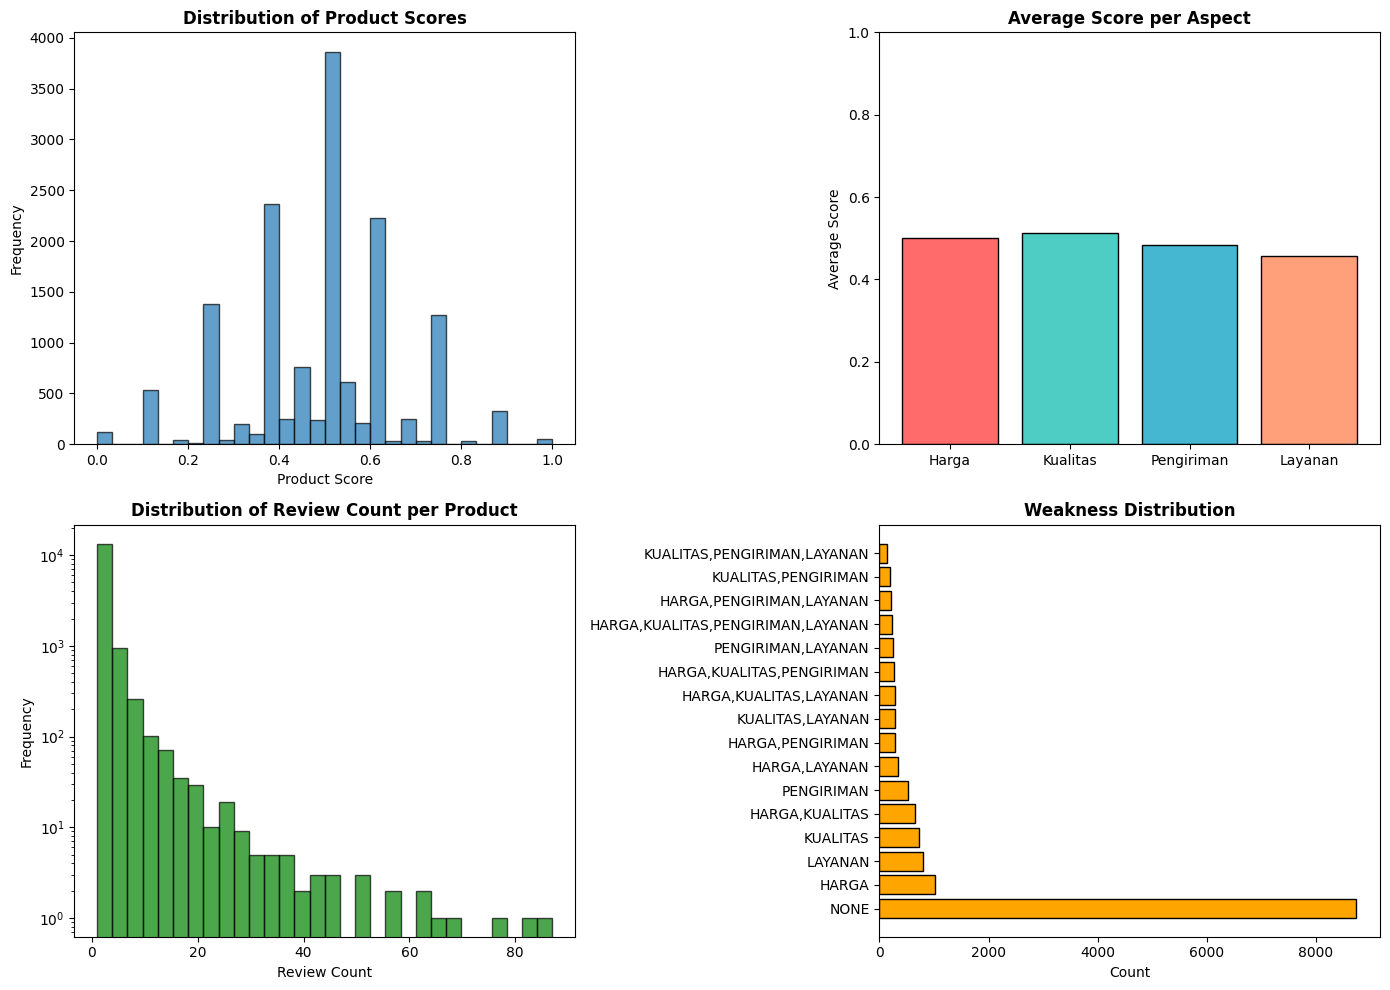

In [15]:
# Distribution of product scores
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Product Score Distribution
axes[0, 0].hist(product_scores_final['product_score'], bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribution of Product Scores', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Product Score')
axes[0, 0].set_ylabel('Frequency')

# Aspect Score Comparison
aspect_means = product_scores_final[['aspect_harga_score', 'aspect_kualitas_score', 
                                       'aspect_pengiriman_score', 'aspect_layanan_score']].mean()
aspects = ['Harga', 'Kualitas', 'Pengiriman', 'Layanan']
axes[0, 1].bar(aspects, aspect_means, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A'], edgecolor='black')
axes[0, 1].set_title('Average Score per Aspect', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Average Score')
axes[0, 1].set_ylim(0, 1)

# Review Count Distribution
axes[1, 0].hist(product_scores_final['review_count'], bins=30, edgecolor='black', alpha=0.7, color='green')
axes[1, 0].set_title('Distribution of Review Count per Product', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Review Count')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_yscale('log')

# Weakness Distribution
weakness_counts = product_scores_final['weakness_flags'].value_counts()
axes[1, 1].barh(range(len(weakness_counts)), weakness_counts.values, color='orange', edgecolor='black')
axes[1, 1].set_yticks(range(len(weakness_counts)))
axes[1, 1].set_yticklabels(weakness_counts.index)
axes[1, 1].set_title('Weakness Distribution', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Count')

plt.tight_layout()
plt.savefig('../04_scoring_engine_visualization.png', dpi=300, bbox_inches='tight')
print("Visualization saved: 04_scoring_engine_visualization.png")
plt.show()

## 7. Summary Statistics

In [16]:
print("SCORING ENGINE - SUMMARY REPORT")

print(f"\n Dataset Info:")
print(f"  - Total Products: {len(product_scores_final)}")
print(f"  - Total Reviews Analyzed: {product_scores_final['review_count'].sum()}")
print(f"  - Avg Reviews per Product: {product_scores_final['review_count'].mean():.2f}")

print(f"\n Product Score Statistics:")
print(f"  - Mean: {product_scores_final['product_score'].mean():.4f}")
print(f"  - Median: {product_scores_final['product_score'].median():.4f}")
print(f"  - Std Dev: {product_scores_final['product_score'].std():.4f}")
print(f"  - Min: {product_scores_final['product_score'].min():.4f}")
print(f"  - Max: {product_scores_final['product_score'].max():.4f}")

print(f"\n Weakness Analysis:")
print(product_scores_final['weakness_flags'].value_counts().to_string())

print(f"\n Output saved to: product_scores.csv")

SCORING ENGINE - SUMMARY REPORT

 Dataset Info:
  - Total Products: 14948
  - Total Reviews Analyzed: 30000
  - Avg Reviews per Product: 2.01

 Product Score Statistics:
  - Mean: 0.4883
  - Median: 0.5000
  - Std Dev: 0.1712
  - Min: 0.0000
  - Max: 1.0000

 Weakness Analysis:
weakness_flags
NONE                                 8738
HARGA                                1026
LAYANAN                               799
KUALITAS                              720
HARGA,KUALITAS                        658
PENGIRIMAN                            530
HARGA,LAYANAN                         343
HARGA,PENGIRIMAN                      288
KUALITAS,LAYANAN                      278
HARGA,KUALITAS,LAYANAN                278
HARGA,KUALITAS,PENGIRIMAN             272
PENGIRIMAN,LAYANAN                    255
HARGA,KUALITAS,PENGIRIMAN,LAYANAN     228
HARGA,PENGIRIMAN,LAYANAN              206
KUALITAS,PENGIRIMAN                   192
KUALITAS,PENGIRIMAN,LAYANAN           137

 Output saved to: product_scores.